#Food Delivery Data Analysis
### Level 3 Final Project
*Student Name:* Amera Ahmed
*Student ID:* 417559

# Task 1: Dataset Understanding & Analysis Planning

## Analysis Objectives

The main objective of this project is to analyze the Food Delivery dataset and generate meaningful business insights that support business decision-making.

The analysis objectives are:

1. Evaluate the overall business performance.
2. Analyze customer ordering behavior.
3. Evaluate restaurant performance.
4. Analyze delivery efficiency.
5. Study customer satisfaction using ratings.
6. Compare payment methods.
7. Analyze the impact of discounts on orders

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [128]:
df = pd.read_csv("Food_Delivery (1).csv")

## Preview Dataset

In [129]:
df.head()

,order_id,customer_id,restaurant,city,order_date,delivery_time_minutes,item,quantity,price,discount,payment_method,rating
0,1,1102,Kebab House,alex,2024-01-01 00:00:00,40.0,Kebab,4,265,13,Wallet,1.0
1,2,1435,Sushi World,alex,2024-01-01 01:00:00,30.0,Pasta,2,241,5,Card,3.0
2,3,1860,Burger Town,Cairo,2024-01-01 02:00:00,NaN,Pasta,3,240,13,Wallet,2.0
3,4,1270,Sushi World,cairo,2024-01-01 03:00:00,43.0,Kebab,3,269,16,Wallet,2.0
4,5,1106,Burger Town,Cairo,2024-01-01 04:00:00,12.0,Pizza,1,129,17,Cash,2.0


The preview above displays the first five rows of the dataset and confirms that the dataset has been loaded successfully.

## Dataset Shape

In [130]:
df.shape

(2050, 12)

The dataset contains 2050 rows and 12 columns before data cleaning.

## Dataset Columns

In [131]:
df.columns

Index(['order_id', 'customer_id', 'restaurant', 'city', 'order_date',
       'delivery_time_minutes', 'item', 'quantity', 'price', 'discount',
       'payment_method', 'rating'],
      dtype='object')

The dataset contains information about orders, customers, restaurants, cities, delivery performance, pricing, discounts, payment methods, and customer ratings.

## Dataset Information

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               2050 non-null   int64  
 1   customer_id            2050 non-null   int64  
 2   restaurant             2050 non-null   object 
 3   city                   1947 non-null   object 
 4   order_date             2050 non-null   object 
 5   delivery_time_minutes  1943 non-null   float64
 6   item                   2050 non-null   object 
 7   quantity               2050 non-null   int64  
 8   price                  2050 non-null   int64  
 9   discount               2050 non-null   int64  
 10  payment_method         2050 non-null   object 
 11  rating                 1945 non-null   float64
dtypes: float64(2), int64(5), object(5)
memory usage: 192.3+ KB


The dataset contains both numerical and categorical variables.

Numerical Variables:
- delivery_time_minutes
- quantity
- price
- discount
- rating

Categorical Variables:
- restaurant
- city
- item
- payment_method

## Descriptive Statistics

In [133]:
df.describe()

,order_id,customer_id,delivery_time_minutes,quantity,price,discount,rating
count,2050.000000,2050.000000,1943.000000,2050.000000,2050.000000,2050.000000,1945.000000
mean,1000.057073,1499.454634,35.249614,2.650244,172.146829,14.497561,2.972751
std,577.001897,294.397792,18.997235,2.402641,71.659016,8.451408,1.412677
min,1.000000,1000.000000,-3.000000,1.000000,50.000000,0.000000,1.000000
25%,501.250000,1232.000000,26.000000,1.000000,111.000000,7.000000,2.000000
50%,1001.500000,1505.000000,35.000000,3.000000,170.000000,15.000000,3.000000
75%,1497.750000,1761.000000,43.000000,4.000000,233.750000,22.000000,4.000000
max,2000.000000,1998.000000,292.000000,41.000000,299.000000,29.000000,5.000000


The descriptive statistics summarize the numerical variables by providing measures such as count, mean, standard deviation, minimum, maximum, and quartiles.

## Dataset Understanding

### Initial Observations

- The dataset contains 2050 food delivery orders.
- The dataset includes customer information, restaurant information, delivery details, pricing information, and customer ratings.
- Both numerical and categorical variables are available.
- The dataset is suitable for analyzing business performance, customer behavior, restaurant performance, and delivery efficiency.
- Data quality assessment is required before performing exploratory data analysis.

# Task 2: Data Quality Assessment & Preparation

## Data Quality Assessment

In [134]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant,0
city,103
order_date,0
delivery_time_minutes,107
item,0
quantity,0
price,0
discount,0


### Missing Values Assessment

The dataset contains missing values in the following columns:

- city
- delivery_time_minutes
- rating

These missing values should be handled before starting the analysis to ensure reliable results.

## Duplicate Records Assessment

In [135]:
df.duplicated().sum()

np.int64(50)

The dataset contains duplicate records that may affect the accuracy of the analysis.

## Remove Duplicate Records

In [136]:
df.drop_duplicates(inplace=True)

In [137]:
df.duplicated().sum()

np.int64(0)

### Verification

The duplicate records have been removed successfully.

## Handle Missing Values

In [138]:
df["city"].fillna(df["city"].mode()[0], inplace=True)

df["delivery_time_minutes"].fillna(
    df["delivery_time_minutes"].median(),
    inplace=True
)

df["rating"].fillna(
    df["rating"].median(),
    inplace=True
)

/tmp/ipykernel_2301/1568731519.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["city"].fillna(df["city"].mode()[0], inplace=True)
/tmp/ipykernel_2301/1568731519.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [139]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant,0
city,0
order_date,0
delivery_time_minutes,0
item,0
quantity,0
price,0
discount,0


### Missing Value Treatment

The missing values were handled as follows:

- The missing values in *city* were replaced with the most frequent city (mode).
- The missing values in *delivery_time_minutes* were replaced with the median because it is less affected by extreme values.
- The missing values in *rating* were also replaced with the median.

## Resolve Data Inconsistencies

In [140]:
df["payment_method"].unique()

array(['Wallet', 'Card', 'Cash'], dtype=object)

In [141]:
df["payment_method"] = df["payment_method"].str.title()

In [142]:
df["payment_method"].unique()

array(['Wallet', 'Card', 'Cash'], dtype=object)

The payment method values were standardized to ensure consistent formatting.

## Prepare Data for Analysis

In [143]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [144]:
df["final_price"] = df["price"] - df["discount"]

A new feature called *final_price* was created to represent the amount paid after applying the discount.

## Identify Potential Outliers

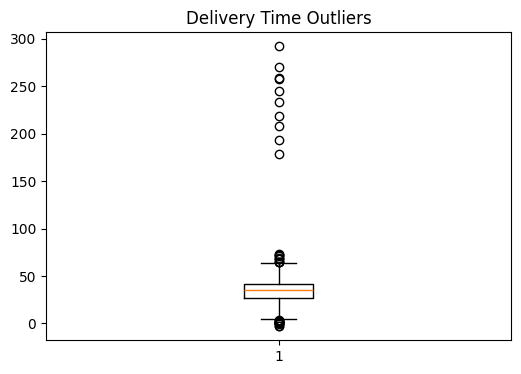

In [145]:
plt.figure(figsize=(6,4))
plt.boxplot(df["delivery_time_minutes"])
plt.title("Delivery Time Outliers")
plt.show()

The box plot was used to identify potential outliers in delivery times. These values should be reviewed to determine whether they represent valid business events or data quality issues.

## Data Quality Summary

The dataset was successfully prepared for analysis by:

- Removing duplicate records.
- Handling missing values.
- Standardizing data formatting.
- Converting the order date to the correct data type.
- Creating a new feature (*final_price*) for analysis.

The dataset is now ready for Exploratory Data Analysis (EDA).

# Task 3: Exploratory Data Analysis (EDA)

## Descriptive Statistics

In [146]:
df.describe()

,order_id,customer_id,order_date,delivery_time_minutes,quantity,price,discount,rating,final_price
count,2000.000000,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,1000.500000,1498.918500,2024-02-11 15:29:59.999999744,35.308500,2.657500,172.035000,14.521500,2.982500,157.51350
min,1.000000,1000.000000,2024-01-01 00:00:00,-3.000000,1.000000,50.000000,0.000000,1.000000,23.00000
25%,500.750000,1232.000000,2024-01-21 19:45:00,27.000000,1.000000,111.000000,7.000000,2.000000,96.00000
50%,1000.500000,1503.000000,2024-02-11 15:30:00,35.000000,3.000000,170.000000,15.000000,3.000000,157.00000
75%,1500.250000,1761.000000,2024-03-03 11:15:00,42.000000,4.000000,233.000000,22.000000,4.000000,218.00000
max,2000.000000,1998.000000,2024-03-24 07:00:00,292.000000,41.000000,299.000000,29.000000,5.000000,296.00000
std,577.494589,294.301136,NaN,18.620249,2.425311,71.491428,8.475698,1.375914,72.08522


### Interpretation

The descriptive statistics summarize the numerical variables and provide information about the average values, spread, minimum, maximum, and overall distribution of the data.

## Analyze Numerical Variables

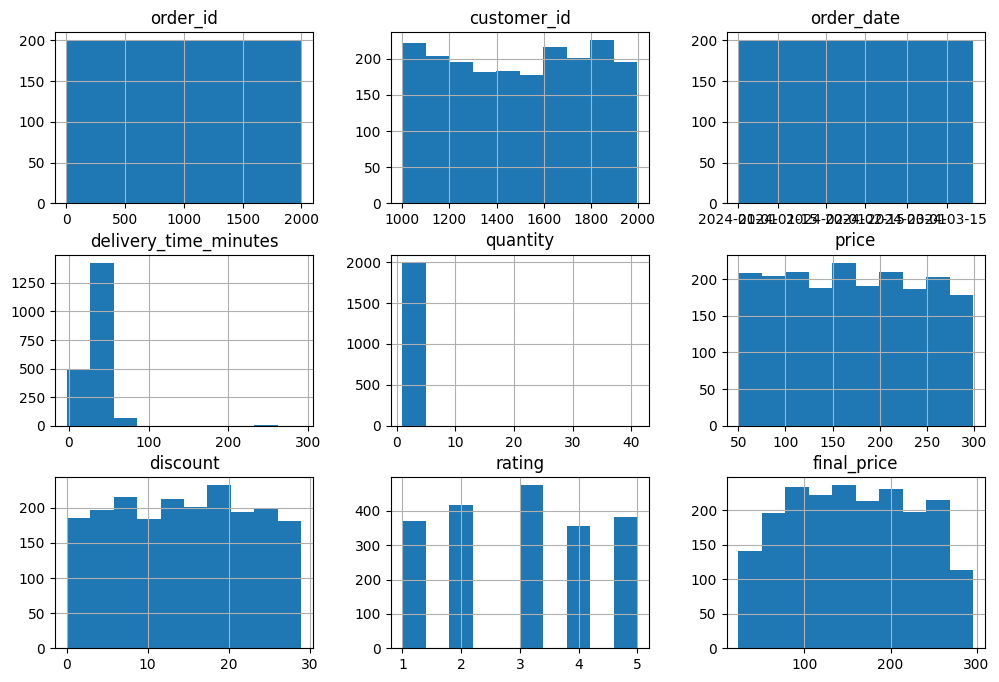

In [147]:
df.hist(figsize=(12,8))
plt.show()

The histograms illustrate the distribution of numerical variables and help identify patterns, skewness, and potential outliers.

## Analyze Categorical Variables

In [148]:
df["restaurant"].value_counts()

,count
restaurant,
Kebab House,424
Pasta Point,415
Pizza Hub,393
Burger Town,387
Sushi World,381


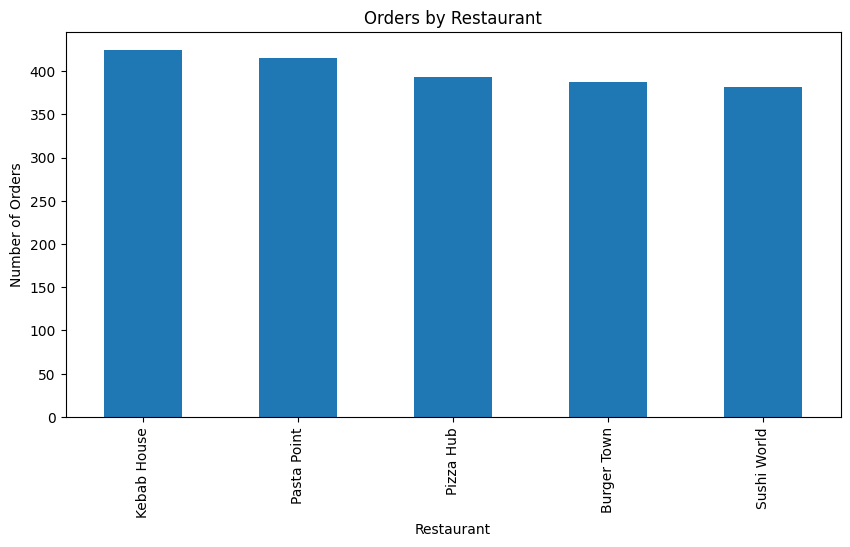

In [149]:
df["restaurant"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Orders by Restaurant")
plt.xlabel("Restaurant")
plt.ylabel("Number of Orders")
plt.show()

In [150]:
df["city"].value_counts()

,count
city,
CAIRO,437
Cairo,326
alex,321
Alex,320
Giza,302
cairo,294


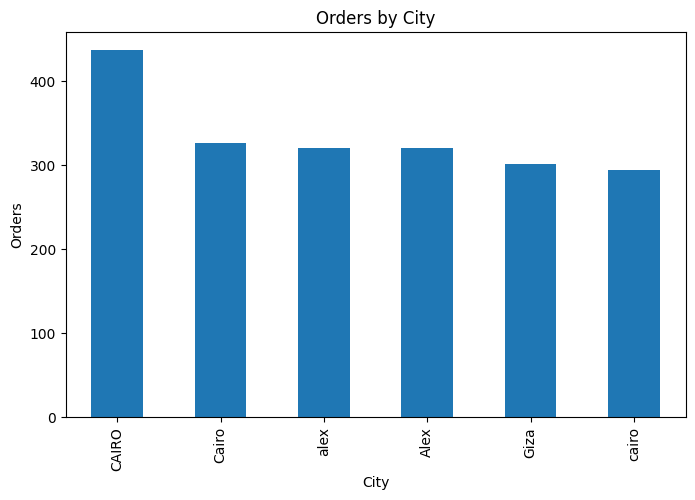

In [151]:
df["city"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Orders by City")
plt.xlabel("City")
plt.ylabel("Orders")
plt.show()

In [152]:
df["payment_method"].value_counts()

,count
payment_method,
Wallet,680
Cash,663
Card,657


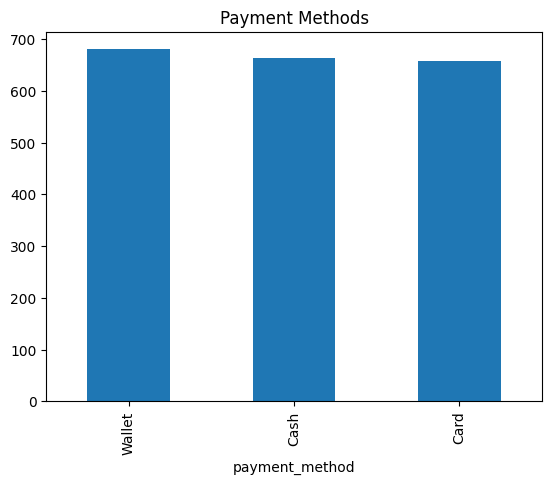

In [153]:
df["payment_method"].value_counts().plot(kind="bar")
plt.title("Payment Methods")
plt.show()

The charts above summarize the distribution of restaurants, cities, and payment methods in the dataset.

## Explore Relationships Between Variables

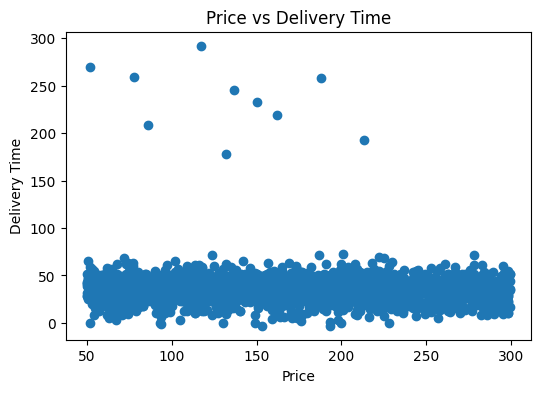

In [154]:
plt.figure(figsize=(6,4))
plt.scatter(df["price"], df["delivery_time_minutes"])
plt.xlabel("Price")
plt.ylabel("Delivery Time")
plt.title("Price vs Delivery Time")
plt.show()

In [155]:
df.groupby("restaurant")["rating"].mean().sort_values(ascending=False)

,rating
restaurant,
Kebab House,3.075472
Sushi World,3.013123
Burger Town,3.010336
Pizza Hub,2.926209
Pasta Point,2.886747


In [156]:
df.groupby("city")["delivery_time_minutes"].mean().sort_values()

,delivery_time_minutes
city,
Alex,34.415625
cairo,35.112245
Cairo,35.159509
alex,35.504673
CAIRO,35.631579
Giza,35.930464


In [157]:
df.groupby("payment_method")["price"].mean()

,price
payment_method,
Card,169.899543
Cash,174.082956
Wallet,172.101471


The relationship analysis helps identify patterns between delivery time, price, restaurant performance, city performance, and payment methods.

## Review Data Subsets

In [158]:
fast_delivery = df[df["delivery_time_minutes"] <= 30]
slow_delivery = df[df["delivery_time_minutes"] > 30]

print("Fast Deliveries:", len(fast_delivery))
print("Slow Deliveries:", len(slow_delivery))

Fast Deliveries: 705
Slow Deliveries: 1295


The dataset was divided into fast and slow deliveries to compare delivery performance.

## Feature Engineering

In [159]:
df["Delivery_Speed"] = np.where(
    df["delivery_time_minutes"] <= 30,
    "Fast",
    "Slow"
)

In [160]:
df["Delivery_Speed"].value_counts()

,count
Delivery_Speed,
Slow,1295
Fast,705


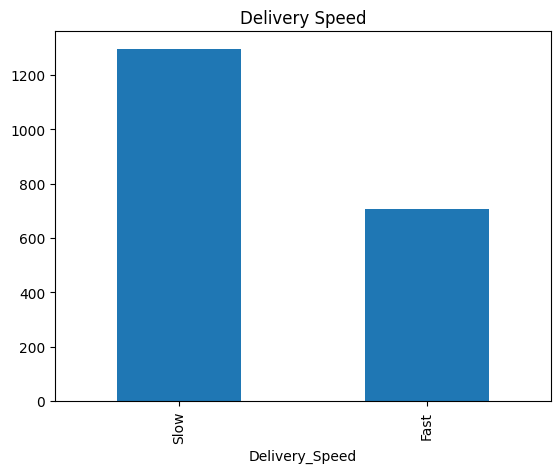

In [161]:
df["Delivery_Speed"].value_counts().plot(kind="bar")
plt.title("Delivery Speed")
plt.show()

A new feature called *Delivery_Speed* was created to classify deliveries into Fast and Slow categories.

## Data Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

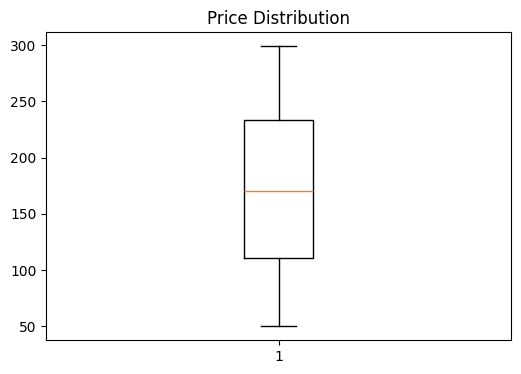

In [162]:
plt.figure(figsize=(6,4))
plt.boxplot(df["price"])
plt.title("Price Distribution")
plt.show

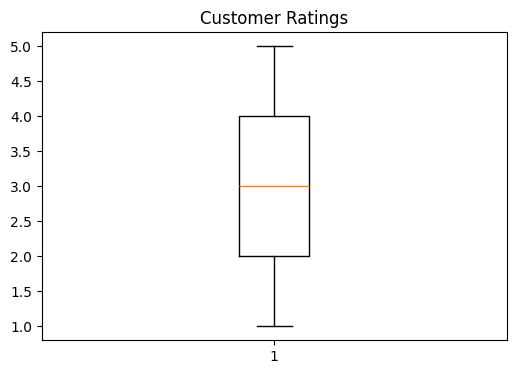

In [163]:
plt.figure(figsize=(6,4))
plt.boxplot(df["rating"])
plt.title("Customer Ratings")
plt.show()

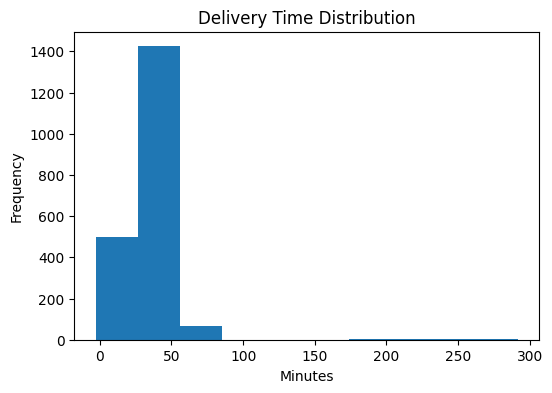

In [164]:
plt.figure(figsize=(6,4))
plt.hist(df["delivery_time_minutes"])
plt.title("Delivery Time Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

The visualizations summarize important business patterns related to prices, ratings, and delivery times. These charts support the exploratory analysis and help identify trends and unusual observations.

# Task 4: Interpretation, Insights & Conclusions

## Interpret Results & Generate Insights

### Key Findings

- The dataset contains valuable information about customer orders, restaurants, delivery performance, and payment methods.
- Some restaurants received more orders than others, indicating differences in customer demand.
- Delivery time varied between orders, suggesting differences in operational efficiency.
- Customer ratings generally reflected the quality of the delivery experience.
- Discounts affected the final order price and may influence customer purchasing behavior.

### Business Insights

- Restaurants with higher order volumes may require additional operational support during peak periods.
- Faster delivery times can improve customer satisfaction and increase the likelihood of positive ratings.
- Monitoring customer ratings helps identify areas that need service improvement.
- Discounts can encourage customers to place more orders when used effectively.

## Answer Analysis Objectives

### Objective 1: Evaluate Business Performance

The dataset provides useful information about sales, orders, restaurants, and delivery operations, allowing management to monitor overall business performance.

### Objective 2: Analyze Customer Behavior

Customer ordering patterns, payment methods, and ratings were successfully analyzed.

### Objective 3: Evaluate Restaurant Performance

Restaurant performance was evaluated by comparing order counts and average customer ratings.

### Objective 4: Evaluate Delivery Efficiency

Delivery times were analyzed to identify delivery performance and possible operational improvements.

### Objective 5: Analyze Customer Satisfaction

Customer ratings were reviewed as an indicator of service quality.

### Objective 6: Compare Payment Methods

Payment methods were analyzed to understand customer payment preferences.

### Objective 7: Analyze Discount Impact

Discounts were compared with prices to evaluate their effect on customer purchases.

## Business Recommendations

### Recommendation 1

Improve delivery operations in areas with longer delivery times to increase customer satisfaction.

### Recommendation 2

Continue monitoring restaurant performance and provide additional support to restaurants with high customer demand.

### Recommendation 3

Use customer ratings regularly to identify service quality issues and improve the customer experience.

### Recommendation 4

Develop targeted discount campaigns to encourage more customer purchases while maintaining profitability.

## Final Conclusion

This project followed the complete data analysis workflow, beginning with understanding the business problem and ending with business recommendations.

The dataset was cleaned, prepared, and explored using descriptive statistics, visualizations, relationship analysis, and feature engineering.

The analysis provided meaningful insights into customer behavior, restaurant performance, delivery efficiency, payment methods, and customer satisfaction.

The findings and recommendations generated from this project can help management make data-driven decisions and improve overall business performance.